In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler


In [2]:
df = pd.read_csv('data/Test.csv')
df.head()


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [4]:
df = df.dropna()
df = df.drop(columns=['ID','Var_1'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2154 entries, 0 to 2626
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2154 non-null   object 
 1   Ever_Married     2154 non-null   object 
 2   Age              2154 non-null   int64  
 3   Graduated        2154 non-null   object 
 4   Profession       2154 non-null   object 
 5   Work_Experience  2154 non-null   float64
 6   Spending_Score   2154 non-null   object 
 7   Family_Size      2154 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 151.5+ KB


In [ ]:
encoder = LabelEncoder()

object_columns = df.select_dtypes(include=['object']).columns

for col in object_columns:
    df[col] = encoder.fit_transform(df[col])

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,0,1,36,1,2,0.0,2,1.0
1,1,1,37,1,5,8.0,0,4.0
3,1,1,59,0,4,11.0,1,2.0
5,1,1,47,1,1,0.0,1,5.0
6,1,1,61,1,1,5.0,2,3.0


In [ ]:
scaler = MinMaxScaler()
df = scaler.fit_transform(df)

[[0.         1.         0.25352113 ... 0.         1.         0.        ]
 [1.         1.         0.26760563 ... 0.57142857 0.         0.375     ]
 [1.         1.         0.57746479 ... 0.78571429 0.5        0.125     ]
 ...
 [0.         0.         0.23943662 ... 0.07142857 1.         0.        ]
 [1.         1.         0.4084507  ... 0.07142857 0.5        0.5       ]
 [0.         0.         0.35211268 ... 0.64285714 1.         0.25      ]]


In [7]:
from algorithm.k_mean import KMeans as kmeans
model = kmeans(k=3, max_iters=100, tol=1e-4)
labels = model.fit(df)
print(model.centroids)


Converged at iteration 4
[[0.48752834 0.         0.19435662 0.50566893 0.38137755 0.21639132
  1.         0.25255102]
 [1.         1.         0.46519969 0.69496021 0.32692308 0.15706707
  0.47745358 0.22330902]
 [0.         1.         0.4831421  0.72393822 0.29898649 0.16078323
  0.45849421 0.19980695]]


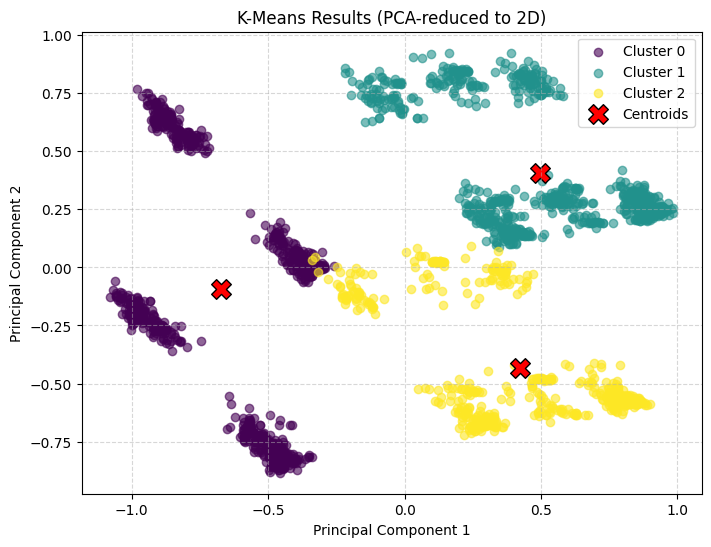

In [8]:
model.plot_clusters(df, labels)